# **INTEGRATION OF ENVIRONMENTAL & ANTHROPOGENIC DRIVERS**

This notebook is intentionally split into two distinct analytical tracks.

**Track A: Forecasting**  

*Goal*: predict future population abundance as accurately as possible.  

*Core signal*: biodiversity history through lagged population features.  
Use of environmental data: additional information on top of the lag-based baseline.

**Track B: Environmental driver analysis**  

*Goal*: identify which climate and anthropogenic variables are most associated with population trend dynamics.  

*Core signal*: environmental features only, without biodiversity lags.  
Use of the output: interpretability, not leaderboard-style forecasting.

This separation avoids mixing two different scientific questions:
1. What predicts best?
2. What environmental factors appear most relevant?

The notebook also provides a final population-level function that, given a population ID and a prediction horizon up to 20 years, returns:
- historical records and future forecast
- approximate confidence intervals
- top environmental drivers with percentage contributions when meaningful
- optional IUCN lookup information if user-supplied lookup tables are available
- a JSON config file ready for plotting or downstream app integration

**BREAKDOWN**

1. Load and reshape the biodiversity panel  
2. Clean and harmonize environmental datasets into a single country-year panel  
3. Merge environmental data onto the biodiversity timeline  
4. Build transformed environmental features  
5. Build lagged biodiversity forecasting features  
6. Run global forecasting experiments  
7. Run global environmental driver experiments  
8. Define a population-level analysis function  
9. Export a JSON config for application or UI use

### IMPORT

In [2]:
from pathlib import Path
import json
import math
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

### CONFIGURATION

In [3]:
from pathlib import Path

NOTEBOOK_DIR = Path(".").resolve()

def first_existing(paths):
    for p in paths:
        p = Path(p).resolve()
        if p.exists():
            return p
    return None

# Resolve project root robustly
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = first_existing([
        NOTEBOOK_DIR,
        NOTEBOOK_DIR.parent,
        NOTEBOOK_DIR.parent.parent,
    ])

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not determine PROJECT_ROOT.")

# Main data folders
CLIMATE_DIR = first_existing([
    PROJECT_ROOT / "data" / "external" / "climate_anthro",
    NOTEBOOK_DIR / "../data/external/climate_anthro",
])

if CLIMATE_DIR is None:
    raise FileNotFoundError(
        "Could not find climate_anthro folder. Expected something like: PROJECT_ROOT/data/external/climate_anthro"
    )

BIODIVERSITY_PATH = first_existing([
    PROJECT_ROOT / "data" / "interim" / "strict_forecasting" / "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv",
    NOTEBOOK_DIR / "../data/interim/strict_forecasting/lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv",
    NOTEBOOK_DIR / "lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv",
    NOTEBOOK_DIR / "biodiversity.csv",
])

if BIODIVERSITY_PATH is None:
    raise FileNotFoundError(
        "Could not find biodiversity CSV. Check the strict_forecasting path or place the file in the notebook folder."
    )

ENV_FILES = {
    "temperature": CLIMATE_DIR / "average-annual-surface-temperature.csv",
    "precipitation": CLIMATE_DIR / "average-precipitation-per-year.csv",
    "forest_share": CLIMATE_DIR / "forest-area-as-share-of-land-area.csv",
    "forest_change": CLIMATE_DIR / "annual-change-forest-area.csv",
    "agricultural_land": CLIMATE_DIR / "agricultural-land.csv",
    "wildfire": CLIMATE_DIR / "annual-area-burnt-per-wildfire.csv",
    "urban_share": CLIMATE_DIR / "urban-population-share-2050.csv",
}

# Outputs at the same level as notebooks
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = OUTPUT_DIR / "population_reports"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Optional lookup templates
IUCN_CURRENT_PATH = first_existing([
    PROJECT_ROOT / "iucn_current_lookup_template.csv",
    NOTEBOOK_DIR / "iucn_current_lookup_template.csv",
])

IUCN_FUTURE_PATH = first_existing([
    PROJECT_ROOT / "iucn_future_scenario_template.csv",
    NOTEBOOK_DIR / "iucn_future_scenario_template.csv",
])

# Global settings
N_LAGS = 4
GLOBAL_TEST_YEARS = 5
RANDOM_STATE = 42
MAX_FORECAST_HORIZON = 20
DEFAULT_POPULATION_ID = None

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("CLIMATE_DIR:", CLIMATE_DIR)
print("BIODIVERSITY_PATH:", BIODIVERSITY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("IUCN_CURRENT_PATH:", IUCN_CURRENT_PATH)
print("IUCN_FUTURE_PATH:", IUCN_FUTURE_PATH)

print("\nEnvironmental files:")
for name, path in ENV_FILES.items():
    print(f"  - {name}: {path} | exists={path.exists()}")

NOTEBOOK_DIR: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\notebooks
PROJECT_ROOT: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction
CLIMATE_DIR: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\external\climate_anthro
BIODIVERSITY_PATH: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\data\interim\strict_forecasting\lpd_terrestrial_strict_last2020_unitsusable_global_zeroskeep.csv
OUTPUT_DIR: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\outputs
REPORT_DIR: C:\Users\Vaccari\Desktop\iCloudDrive\Deskt

In [4]:
if BIODIVERSITY_PATH is None:
    raise FileNotFoundError(
        "Biodiversity file not found. Update BIODIVERSITY_PATH in the config cell before running the notebook."
    )

missing_env = [name for name, path in ENV_FILES.items() if not path.exists() and name != "glaciers"]
if missing_env:
    print("Warning: some environmental files are missing:", missing_env)


### COUNTRY HARMONIZATION


The environmental panel and the biodiversity panel may use slightly different country strings. The normalization below keeps the logic transparent and deterministic rather than overly clever.

In [5]:
COUNTRY_ALIASES = {
    "czech republic": "czechia",
    "russian federation": "russia",
    "united states": "united states",
    "united states of america": "united states",
    "usa": "united states",
    "uk": "united kingdom",
    "great britain": "united kingdom",
    "viet nam": "vietnam",
    "lao pdr": "laos",
    "democratic republic of the congo": "democratic republic of congo",
    "congo, dem. rep.": "democratic republic of congo",
    "congo, rep.": "republic of congo",
    "bolivia (plurinational state of)": "bolivia",
    "iran (islamic republic of)": "iran",
    "syrian arab republic": "syria",
    "venezuela (bolivarian republic of)": "venezuela",
    "türkiye": "turkey",
    "myanmar (burma)": "myanmar",
    "moldova, republic of": "moldova",
    "united republic of tanzania": "tanzania",
    "korea, republic of": "south korea",
    "republic of korea": "south korea",
    "korea, dem. people's rep.": "north korea",
    "democratic people's republic of korea": "north korea",
    "brunei darussalam": "brunei",
    "cabo verde": "cape verde",
    "eswatini": "swaziland",
    "palestine": "state of palestine",
    "occupied palestinian territory": "state of palestine",
    "timor-leste": "east timor",
    "micronesia (federated states of)": "micronesia",
    "bahamas, the": "bahamas",
    "gambia, the": "gambia",
}

def normalize_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = x.replace("&", "and")
    x = " ".join(x.split())
    return COUNTRY_ALIASES.get(x, x)

def normalize_country_series(s):
    return s.astype(str).map(normalize_text)

def is_country_row(df):
    if "Code" not in df.columns:
        return pd.Series(True, index=df.index)
    return df["Code"].astype(str).str.fullmatch(r"[A-Z]{3}", na=False)

### BIODIVERSITRY LOADING & RESHAPING

In [6]:
STATIC_NUMERIC_CANDIDATES = ["latitude", "longitude"]
STATIC_CATEGORICAL_CANDIDATES = [
    "class", "family", "order", "genus", "ipbes_subregion",
    "system_group", "t_realm", "t_biome", "units"
]
IDENTIFIER_CANDIDATES = [
    "id", "population_id", "binomial", "common_name", "location", "country"
]

def detect_year_columns(df):
    year_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]
    return sorted(year_cols, key=int)

def choose_population_id_column(df):
    for col in ["population_id", "id"]:
        if col in df.columns:
            return col
    return None

def load_biodiversity_wide(path):
    df = pd.read_csv(path)
    df = df.copy()
    return df

def wide_to_long_biodiversity(df):
    df = df.copy().reset_index(drop=False).rename(columns={"index": "__row_idx__"})
    year_columns = detect_year_columns(df)
    if not year_columns:
        raise ValueError("No year columns detected in biodiversity file.")

    pop_id_col = choose_population_id_column(df)
    if pop_id_col is None:
        df["population_id"] = "pop_" + df["__row_idx__"].astype(str)
        pop_id_col = "population_id"
    else:
        df["population_id"] = df[pop_id_col].astype(str)

    id_columns = [c for c in df.columns if c not in year_columns]
    long_df = df.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="Year",
        value_name="Population"
    )
    long_df["Year"] = long_df["Year"].astype(int)
    long_df = long_df.dropna(subset=["Population"]).copy()
    long_df["Population"] = pd.to_numeric(long_df["Population"], errors="coerce")
    long_df = long_df.dropna(subset=["Population"]).copy()

    if "country" in long_df.columns:
        long_df["country_norm"] = normalize_country_series(long_df["country"])
    else:
        long_df["country_norm"] = np.nan

    long_df["population_id"] = long_df["population_id"].astype(str)
    long_df["series_id"] = long_df["population_id"]
    long_df["log_population"] = np.log1p(long_df["Population"])

    return long_df, year_columns

biodiversity_wide = load_biodiversity_wide(BIODIVERSITY_PATH)
biodiversity_long, biodiversity_year_cols = wide_to_long_biodiversity(biodiversity_wide)

static_numeric_features = [c for c in STATIC_NUMERIC_CANDIDATES if c in biodiversity_wide.columns]
static_categorical_features = [c for c in STATIC_CATEGORICAL_CANDIDATES if c in biodiversity_wide.columns]
identifier_columns = [c for c in IDENTIFIER_CANDIDATES if c in biodiversity_wide.columns]

print("Wide biodiversity shape:", biodiversity_wide.shape)
print("Long biodiversity shape:", biodiversity_long.shape)
print("Year range:", biodiversity_long["Year"].min(), biodiversity_long["Year"].max())
print("N populations:", biodiversity_long["population_id"].nunique())
display(biodiversity_long.head())

Wide biodiversity shape: (49, 126)
Long biodiversity shape: (1349, 62)
Year range: 1980 2020
N populations: 49


,__row_idx__,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,population_id,Year,Population,country_norm,series_id,log_population
1479,9,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,111105,1980,36.0,australia,111105,3.610918
1480,10,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,111106,1980,20.0,australia,111106,3.044522
1523,4,27730,Alces_americanus,0,1,Kluane National Park (2017) ‘Moose Survey Coun...,Mammalia,Artiodactyla,Cervidae,Alces,americanus,NaN,Moose,"Duke, Kluane National Park and Reserve, Yukon",canada,Canada,North America,Americas,North America,60.749785,-139.500032,1,terrestrial,Nearctic,Boreal forests/taiga,NaN,NaN,NaN,NaN,NaN,adult individuals (bulls and cows),1,NaN,36.0,1981.0,2020.0,40.0,4.0,1.0,0.90000,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,27730,1981,81.0,canada,27730,4.406719
1528,9,111105,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,111105,1981,21.0,australia,111105,3.091042
1529,10,111106,Petrogale_xanthopus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Macropodidae,Petrogale,xanthopus,NaN,Yellow-footed Rock-wallaby,Mootwingee Downs,australia,Australia,Oceania,Asia and the Pacific,Oceania,-30.921664,142.435604,0,terrestrial,Australasia,Deserts and xeric shrublands,NaN,NaN,NaN,NaN,NaN,sample: abundance (counts),1,NaN,40.0,1980.0,2020.0,41.0,1.0,1.0,0.97561,0.0,0.0,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,111106,1981,28.0,australia,111106,3.367296


### ENVIRONMENTAL SOURCES

> average surface temporature

> precipitation

> forest_share

> forest_change

> agricultural land (deforestation)

> wildfires

> urbanization


In [7]:
ENV_SPECS = {
    "temperature": {
        "file": ENV_FILES["temperature"],
        "value_col": "Average surface temperature",
        "model_col": "temp_avg_c",
        "type": "climate",
        "transform": None,
        "min_year": 1900,
        "max_year": None,
        "include": True,
    },
    "precipitation": {
        "file": ENV_FILES["precipitation"],
        "value_col": "Annual precipitation",
        "model_col": "precip_mm",
        "type": "climate",
        "transform": None,
        "min_year": 1900,
        "max_year": None,
        "include": True,
    },
    "forest_share": {
        "file": ENV_FILES["forest_share"],
        "value_col": "Share of land covered by forest",
        "model_col": "forest_share_pct",
        "type": "environmental_land_cover",
        "transform": None,
        "min_year": 1900,
        "max_year": None,
        "include": True,
    },
    "forest_change": {
        "file": ENV_FILES["forest_change"],
        "value_col": "Annual change in forest area",
        "model_col": "forest_change_ha",
        "type": "environmental_land_change",
        "transform": None,
        "min_year": 1900,
        "max_year": None,
        "include": True,
    },
    "agricultural_land": {
        "file": ENV_FILES["agricultural_land"],
        "value_col": "Agricultural land - Area (hectares)",
        "model_col": "agricultural_land_log1p",
        "type": "anthropogenic_land_use",
        "transform": "log1p",
        "min_year": 1900,
        "max_year": None,
        "include": True,
    },
    "wildfire": {
        "file": ENV_FILES["wildfire"],
        "value_col": "Annual area burnt per wildfire",
        "model_col": "wildfire_area_ha_per_fire_log1p",
        "type": "climate_disturbance",
        "transform": "log1p",
        "min_year": 1900,
        "max_year": 2025,
        "include": True,
    },
    "urban_share": {
        "file": ENV_FILES["urban_share"],
        "value_col": "Share of population residing in urban areas",
        "model_col": "urban_share_pct",
        "type": "anthropogenic_urban_pressure",
        "transform": None,
        "min_year": 1950,
        "max_year": 2050,
        "include": True,
    },
}

In [8]:
def load_environment_source(name, spec):
    if not spec["file"].exists():
        raise FileNotFoundError(f"Missing file for {name}: {spec['file']}")

    df = pd.read_csv(spec["file"])
    needed = ["Entity", "Year", spec["value_col"]]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")

    if "Code" in df.columns:
        df = df[is_country_row(df)].copy()

    df = df[["Entity"] + ([ "Code" ] if "Code" in df.columns else []) + ["Year", spec["value_col"]]].copy()
    df = df.rename(columns={"Entity": "country_raw", spec["value_col"]: spec["model_col"]})
    df["country_norm"] = normalize_country_series(df["country_raw"])
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df[spec["model_col"]] = pd.to_numeric(df[spec["model_col"]], errors="coerce")

    df = df.dropna(subset=["country_norm", "Year"]).copy()
    df["Year"] = df["Year"].astype(int)

    if spec["min_year"] is not None:
        df = df[df["Year"] >= spec["min_year"]].copy()
    if spec["max_year"] is not None:
        df = df[df["Year"] <= spec["max_year"]].copy()

    if spec["transform"] == "log1p":
        df[spec["model_col"]] = np.log1p(df[spec["model_col"]].clip(lower=0))

    df = (
        df.groupby(["country_norm", "Year"], as_index=False)[spec["model_col"]]
        .mean()
        .sort_values(["country_norm", "Year"])
        .reset_index(drop=True)
    )
    return df

env_tables = {}
for name, spec in ENV_SPECS.items():
    if spec["include"]:
        env_tables[name] = load_environment_source(name, spec)

for name, df in env_tables.items():
    print(name, df.shape, "years:", (df["Year"].min(), df["Year"].max()))
    display(df.head(2))


temperature (16598, 3) years: (1940, 2025)


,country_norm,Year,temp_avg_c
0,afghanistan,1940,11.327695
1,afghanistan,1941,13.324756


precipitation (16512, 3) years: (1940, 2025)


,country_norm,Year,precip_mm
0,afghanistan,1940,217.67816
1,afghanistan,1941,196.80933


forest_share (7673, 3) years: (1900, 2025)


...

,country_norm,Year,agricultural_land_log1p
0,afghanistan,1961,17.446496
1,afghanistan,1962,17.447820


wildfire (2475, 3) years: (2012, 2025)


,country_norm,Year,wildfire_area_ha_per_fire_log1p
0,afghanistan,2012,5.472462
1,afghanistan,2013,5.190428


urban_share (21212, 3) years: (1950, 2050)


,country_norm,Year,urban_share_pct
0,afghanistan,1950,6.098772
1,afghanistan,1951,6.320829


Build the unified country-year environmental panel


In [9]:
def build_environment_panel(env_tables, env_specs):
    panel = None
    for name, spec in env_specs.items():
        if not spec["include"]:
            continue
        source_df = env_tables[name].copy()
        keep_cols = ["country_norm", "Year", spec["model_col"]]
        source_df = source_df[keep_cols].copy()

        if panel is None:
            panel = source_df
        else:
            panel = panel.merge(source_df, on=["country_norm", "Year"], how="outer")

    if panel is None:
        raise ValueError("No environmental tables available to build the panel.")

    panel = panel.sort_values(["country_norm", "Year"]).reset_index(drop=True)
    return panel

env_panel_raw = build_environment_panel(env_tables, ENV_SPECS)
print("Environment panel shape:", env_panel_raw.shape)
display(env_panel_raw.head())

Environment panel shape: (25328, 9)


,country_norm,Year,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_log1p,wildfire_area_ha_per_fire_log1p,urban_share_pct
0,afghanistan,1940,11.327695,217.67816,NaN,NaN,NaN,NaN,NaN
1,afghanistan,1941,13.324756,196.80933,NaN,NaN,NaN,NaN,NaN
2,afghanistan,1942,12.885448,300.08908,NaN,NaN,NaN,NaN,NaN
3,afghanistan,1943,11.524769,345.60892,NaN,NaN,NaN,NaN,NaN
4,afghanistan,1944,12.143665,324.44350,NaN,NaN,NaN,NaN,NaN


**Side note on NaNs:** 

Environmental variables are merged onto the biodiversity panel using a left join on `country_norm` and `Year`. This ensures that the biodiversity time series remains the reference structure, while environmental features are added only when a matching country-year observation is available.

Missing values in climate or anthropogenic variables are not removed immediately after the merge. This choice is intentional, as dropping them at this stage would reduce the effective sample size and compromise the comparability between baseline and enriched models.

In the forecasting pipeline, missing environmental values are handled through imputation within the modeling pipeline. Observations are only excluded when structurally required variables, such as biodiversity lags, are unavailable.

In the local driver analysis, a similar approach is adopted. Rows are excluded only when the target variable cannot be computed, while missing environmental predictors are imputed during model fitting.

As a result, populations with partially missing environmental data are generally retained in the analysis. However, when missingness is extensive, the interpretability of environmental contributions may be reduced, even if the model remains operational.

In [10]:
def add_environmental_features(panel):
    df = panel.sort_values(["country_norm", "Year"]).copy()

    def grouped_shift(col, n=1):
        return df.groupby("country_norm")[col].shift(n)

    def grouped_roll_mean(col, window=3):
        return (
            df.groupby("country_norm")[col]
            .shift(1)
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    def grouped_country_anomaly(col):
        return df[col] - df.groupby("country_norm")[col].transform("mean")

    raw_if_exists = [c for c in [
        "temp_avg_c", "precip_mm", "forest_share_pct", "forest_change_ha",
        "agricultural_land_log1p", "wildfire_area_ha_per_fire_log1p", "urban_share_pct"
    ] if c in df.columns]

    if "temp_avg_c" in df.columns:
        df["temp_change_1y"] = df["temp_avg_c"] - grouped_shift("temp_avg_c", 1)
        df["temp_roll3"] = grouped_roll_mean("temp_avg_c", 3)
        df["temp_anom_country"] = grouped_country_anomaly("temp_avg_c")

    if "precip_mm" in df.columns:
        df["precip_change_1y"] = df["precip_mm"] - grouped_shift("precip_mm", 1)
        df["precip_roll3"] = grouped_roll_mean("precip_mm", 3)
        df["precip_anom_country"] = grouped_country_anomaly("precip_mm")

    if "forest_share_pct" in df.columns:
        df["forest_share_change_1y"] = df["forest_share_pct"] - grouped_shift("forest_share_pct", 1)

    if "agricultural_land_log1p" in df.columns:
        df["agricultural_land_change_1y"] = df["agricultural_land_log1p"] - grouped_shift("agricultural_land_log1p", 1)

    if "wildfire_area_ha_per_fire_log1p" in df.columns:
        base = df["wildfire_area_ha_per_fire_log1p"]
        df["wildfire_occurrence"] = (base.fillna(0) > 0).astype(int)
        df["wildfire_change_1y"] = base - grouped_shift("wildfire_area_ha_per_fire_log1p", 1)
        df["wildfire_roll3"] = grouped_roll_mean("wildfire_area_ha_per_fire_log1p", 3)

    if "urban_share_pct" in df.columns:
        df["urban_share_change_1y"] = df["urban_share_pct"] - grouped_shift("urban_share_pct", 1)

    return df

env_panel = add_environmental_features(env_panel_raw)
print("Environment panel with transformations:", env_panel.shape)
display(env_panel.head())

Environment panel with transformations: (25328, 21)


,country_norm,Year,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_log1p,wildfire_area_ha_per_fire_log1p,urban_share_pct,temp_change_1y,temp_roll3,temp_anom_country,precip_change_1y,precip_roll3,precip_anom_country,forest_share_change_1y,agricultural_land_change_1y,wildfire_occurrence,wildfire_change_1y,wildfire_roll3,urban_share_change_1y
0,afghanistan,1940,11.327695,217.67816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.753880,NaN,NaN,-140.511065,NaN,NaN,0,NaN,NaN,NaN
1,afghanistan,1941,13.324756,196.80933,NaN,NaN,NaN,NaN,NaN,1.997061,NaN,1.243181,-20.86883,NaN,-161.379895,NaN,NaN,0,NaN,NaN,NaN
2,afghanistan,1942,12.885448,300.08908,NaN,NaN,NaN,NaN,NaN,-0.439308,NaN,0.803873,103.27975,NaN,-58.100145,NaN,NaN,0,NaN,NaN,NaN
3,afghanistan,1943,11.524769,345.60892,NaN,NaN,NaN,NaN,NaN,-1.360679,12.512633,-0.556806,45.51984,238.192190,-12.580305,NaN,NaN,0,NaN,NaN,NaN
4,afghanistan,1944,12.143665,324.44350,NaN,NaN,NaN,NaN,NaN,0.618896,12.578324,0.062090,-21.16542,280.835777,-33.745725,NaN,NaN,0,NaN,NaN,NaN


In [11]:
def feature_coverage_summary(df, feature_cols, group_col="country_norm"):
    if not pd.Index(df.columns).is_unique:
        dupes = pd.Index(df.columns)[pd.Index(df.columns).duplicated()].unique().tolist()
        raise ValueError(f"Duplicate column names found: {dupes}")

    rows = []
    for col in feature_cols:
        if col not in df.columns:
            continue
        s = df[col]
        rows.append({
            "feature": col,
            "non_null_rows": int(s.notna().sum()),
            "share_non_null": float(s.notna().mean()),
            "countries_with_data": int(df.loc[s.notna(), group_col].nunique()),
            "year_min_with_data": int(df.loc[s.notna(), "Year"].min()) if s.notna().any() else np.nan,
            "year_max_with_data": int(df.loc[s.notna(), "Year"].max()) if s.notna().any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["share_non_null", "feature"], ascending=[False, True]).reset_index(drop=True)

coverage_features = [c for c in env_panel.columns if c not in ["country_norm", "Year"]]
env_coverage = feature_coverage_summary(env_panel, coverage_features)
display(env_coverage)

,feature,non_null_rows,share_non_null,countries_with_data,year_min_with_data,year_max_with_data
0,wildfire_occurrence,25328,1.000000,243,1900,2050
1,urban_share_pct,21212,0.837492,234,1950,2050
2,urban_share_change_1y,20978,0.828253,234,1951,2050
3,temp_anom_country,16598,0.655322,193,1940,2025
4,temp_avg_c,16598,0.655322,193,1940,2025
5,precip_anom_country,16512,0.651927,192,1940,2025
6,precip_mm,16512,0.651927,192,1940,2025
7,temp_change_1y,16405,0.647702,193,1941,2025
8,precip_change_1y,16320,0.644346,192,1941,2025
9,temp_roll3,16210,0.640003,193,1943,2026


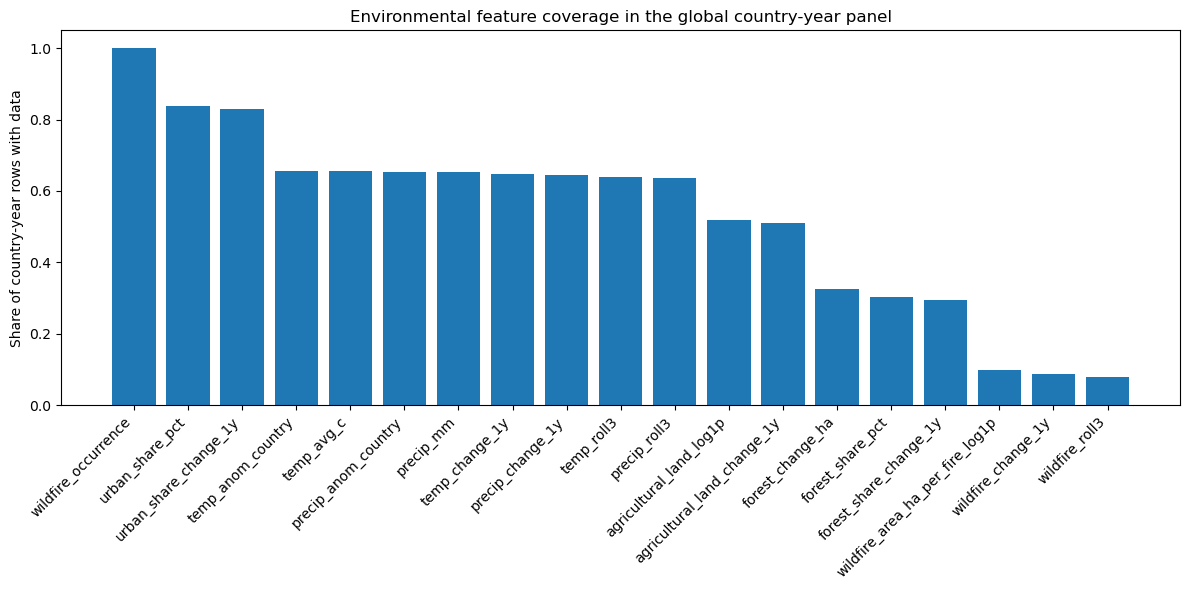

In [12]:
plt.figure(figsize=(12, 6))
plot_df = env_coverage.sort_values("share_non_null", ascending=False)
plt.bar(plot_df["feature"], plot_df["share_non_null"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Share of country-year rows with data")
plt.title("Environmental feature coverage in the global country-year panel")
plt.tight_layout()
plt.show()


This plot shows the coverage of each environmental feature in the global country-year panel. Below is a description of each feature and the type of values it can take.

Temperature-related features  
- `temp_avg_c`: Average annual surface temperature in degrees Celsius. Continuous numeric variable.  
- `temp_anom_country`: Temperature anomaly relative to the country’s historical average. Can be positive or negative (°C).  
- `temp_roll3`: 3-year rolling mean of temperature. Continuous numeric, smoother version of temperature.  
- `temp_change_1y`: Year-to-year change in temperature. Can be positive or negative (°C).

Precipitation-related features  
- `precip_mm`: Total annual precipitation in millimeters. Continuous positive variable.  
- `precip_anom_country`: Precipitation anomaly relative to country average. Can be positive or negative (mm).  
- `precip_roll3`: 3-year rolling mean of precipitation. Continuous positive variable.  
- `precip_change_1y`: Year-to-year change in precipitation. Can be positive or negative (mm).

Forest and land cover features  
- `forest_share_pct`: Forest area as a percentage of total land area. Values typically between 0 and 100.  
- `forest_change_ha`: Annual change in forest area (hectares). Can be positive (gain) or negative (loss).  
- `forest_share_change_1y`: Yearly change in forest share percentage. Can be positive or negative.

Agricultural land features  
- `agricultural_land_log1p`: Log-transformed agricultural land area. Positive continuous variable (log scale).  
- `agricultural_land_change_1y`: Yearly change in agricultural land area. Can be positive or negative.

Urbanization features  
- `urban_share_pct`: Share of population living in urban areas (%). Typically between 0 and 100.  
- `urban_share_change_1y`: Yearly change in urban population share. Can be positive or negative.

Wildfire features  
- `wildfire_area_ha_per_fire_log1p`: Log-transformed average area burned per wildfire event. Positive continuous variable.  
- `wildfire_occurrence`: Binary variable (0 or 1) indicating whether wildfire activity occurred in that year.  
- `wildfire_change_1y`: Year-to-year change in wildfire activity. Can be positive or negative.  
- `wildfire_roll3`: 3-year rolling measure of wildfire activity. Continuous, smoothed indicator.

General notes  
- “_change_1y” features capture short-term dynamics (year-to-year variation).  
- “_roll3” features capture medium-term trends by smoothing noise.  
- “_anom_country” features represent deviations from a country-specific baseline, making them more comparable across regions.  
- Log-transformed features (e.g., `log1p`) reduce skewness and stabilize variance.

These transformations are designed to better capture ecological responses, which are often driven by trends, anomalies, and shocks rather than raw absolute values.

### ENVIRONMENTAL + BIODIVERSITY DATA MERGE

The biodiversity panel defines the reference sample.  
Environmental data are attached by `country_norm + Year` using a left join.  
Rows are not dropped immediately after the merge. Missing environmental values are left in place and later handled via imputation inside the model pipeline.

In [ ]:
merged_long = biodiversity_long.merge(
    env_panel,
    on=["country_norm", "Year"],
    how="left"
).sort_values(["population_id", "Year"]).reset_index(drop=True)

print("Merged long shape:", merged_long.shape)
display(merged_long.head())

Merged long shape: (1349, 81)


,__row_idx__,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,population_id,Year,Population,country_norm,series_id,log_population,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_log1p,wildfire_area_ha_per_fire_log1p,urban_share_pct,temp_change_1y,temp_roll3,temp_anom_country,precip_change_1y,precip_roll3,precip_anom_country,forest_share_change_1y,agricultural_land_change_1y,wildfire_occurrence,wildfire_change_1y,wildfire_roll3,urban_share_change_1y
0,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1982,1.111111,australia,110261,0.747214,21.816086,400.80215,NaN,NaN,20.011490,NaN,85.486046,-0.159811,22.167697,-0.165862,-124.04679,460.250347,-46.08984,NaN,-0.009719,0,NaN,NaN,-0.100414
1,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1983,0.000000,australia,110261,0.000000,22.079447,505.49710,NaN,NaN,19.997159,NaN,85.399925,0.263361,22.089626,0.097499,104.69495,445.882663,58.60511,NaN,-0.014331,0,NaN,NaN,-0.086121
2,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1984,0.714286,australia,110261,0.538997,21.377413,554.88350,NaN,NaN,20.002867,NaN,85.363525,-0.702034,21.957143,-0.604535,49.38640,477.049397,107.99151,NaN,0.005707,0,NaN,NaN,-0.036400
3,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1985,1.190476,australia,110261,0.784119,21.955000,412.62817,NaN,NaN,20.003345,NaN,85.396805,0.577587,21.757649,-0.026948,-142.25533,487.060917,-34.26382,NaN,0.000479,0,NaN,NaN,0.033280
4,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodonti

### POPULATION HISTORY FEATURES FOR FORECASTING

In [14]:
def add_population_lag_features(df, n_lags=4):
    out = df.sort_values(["population_id", "Year"]).copy()
    grouped = out.groupby("population_id")["Population"]

    for lag in range(1, n_lags + 1):
        out[f"lag_{lag}"] = grouped.shift(lag)

    out["prev_year"] = out.groupby("population_id")["Year"].shift(1)
    out["year_gap_from_prev"] = out["Year"] - out["prev_year"]

    out["rolling_mean_3"] = (
        grouped.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    )
    out["rolling_std_3"] = (
        grouped.shift(1).rolling(3).std().reset_index(level=0, drop=True)
    )

    out["population_difference"] = out["lag_1"] - out["lag_2"]
    out["population_growth_rate"] = (
        (out["lag_1"] - out["lag_2"]) / out["lag_2"].replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

    return out

def add_driver_target(df):
    out = df.sort_values(["population_id", "Year"]).copy()
    out["log_population_prev"] = out.groupby("population_id")["log_population"].shift(1)
    out["pop_change_log"] = out["log_population"] - out["log_population_prev"]
    return out

merged_long = add_driver_target(merged_long)
forecast_long = add_population_lag_features(merged_long, n_lags=N_LAGS)

required_lags = [f"lag_{i}" for i in range(1, N_LAGS + 1)]
forecast_long = forecast_long.dropna(subset=required_lags).copy()

print("Forecast panel shape:", forecast_long.shape)
display(forecast_long.head())


Forecast panel shape: (1153, 93)


,__row_idx__,id,binomial,replicate,included_in_lpr2024,citation,class,order,family,genus,species,subspecies,common_name,location,country,all_countries,region,ipbes_region,ipbes_subregion,latitude,longitude,specific_location,system,t_realm,t_biome,fw_realm,fw_biome,m_realm,m_ocean,m_biome,units,native,unnamed_102,n_obs,first_obs_year,last_obs_year,time_span,n_gaps,max_gap,continuity_ratio,zero_count,zero_share,years_since_last_obs,has_coordinates,has_country,has_valid_coordinates,has_binomial,has_class,has_order,has_family,has_genus,has_species,has_taxonomy_hierarchy,unit_category,unit_usable,system_group,population_id,Year,Population,country_norm,series_id,log_population,temp_avg_c,precip_mm,forest_share_pct,forest_change_ha,agricultural_land_log1p,wildfire_area_ha_per_fire_log1p,urban_share_pct,temp_change_1y,temp_roll3,temp_anom_country,precip_change_1y,precip_roll3,precip_anom_country,forest_share_change_1y,agricultural_land_change_1y,wildfire_occurrence,wildfire_change_1y,wildfire_roll3,urban_share_change_1y,log_population_prev,pop_change_log,lag_1,lag_2,lag_3,lag_4,prev_year,year_gap_from_prev,rolling_mean_3,rolling_std_3,population_difference,population_growth_rate
4,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1986,1.285714,australia,110261,0.826679,21.988586,400.56122,NaN,NaN,19.965134,NaN,85.315765,0.033586,21.803953,0.006638,-12.06695,491.002923,-46.33077,NaN,-0.038211,0,NaN,NaN,-0.081040,0.784119,0.042560,1.190476,0.714286,0.000000,1.111111,1985.0,1.0,0.634921,0.599193,0.476190,0.666667
5,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1987,4.000000,australia,110261,1.609438,21.950060,469.45460,NaN,NaN,19.970411,NaN,85.358696,-0.038526,21.773666,-0.031888,68.89338,456.024297,22.56261,NaN,0.005277,0,NaN,NaN,0.042931,0.826679,0.782759,1.285714,1.190476,0.714286,0.000000,1986.0,1.0,1.063492,0.306148,0.095238,0.080000
6,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# presences/# surveys = tra...,1,NaN,39.0,1982.0,2020.0,39.0,0.0,0.0,1.0,1.0,0.025641,0.0,True,True,True,True,True,True,True,True,True,True,direct_count,True,terrestrial,110261,1988,3.125000,australia,110261,1.417066,22.466513,456.87595,NaN,NaN,19.972600,NaN,85.419380,0.516453,21.964549,0.484565,-12.57865,427.547997,9.98396,NaN,0.002189,0,NaN,NaN,0.060684,1.609438,-0.192372,4.000000,1.285714,1.190476,0.714286,1987.0,1.0,2.158730,1.595297,2.714286,2.111111
7,5,110261,Burramys_parvus,0,1,TSX (2023). The Australian Threatened Species ...,Mammalia,Diprotodontia,Burramyidae,Burramys,parvus,NaN,Mountain Pygmy-possum,Victorian Alps,australia,Australia,Oceania,Asia and the Pacific,Oceania,-37.208994,146.845252,0,terrestrial,Australasia,Temperate broadleaf and mixed forests,NaN,NaN,NaN,NaN,NaN,sample: occupancy (# pres

### FEATURES BLOCK & BREAKDOWN

Representative block: one high-level feature per main environmental family.  
Transformed block: richer lag/anomaly/change representation for interpretability and incremental predictive testing.

In [ ]:
POPULATION_LAG_FEATURES = [
    *[f"lag_{i}" for i in range(1, N_LAGS + 1)],
    "year_gap_from_prev",
    "rolling_mean_3",
    "rolling_std_3",
    "population_difference",
    "population_growth_rate",
]
POPULATION_LAG_FEATURES = [c for c in POPULATION_LAG_FEATURES if c in forecast_long.columns]

STATIC_NUMERIC_FEATURES = [c for c in static_numeric_features if c in forecast_long.columns]
STATIC_CATEGORICAL_FEATURES = [c for c in static_categorical_features if c in forecast_long.columns]

ENV_REPRESENTATIVE_FEATURES = [
    "temp_anom_country",
    "precip_anom_country",
    "forest_share_pct",
    "wildfire_occurrence",
    "agricultural_land_log1p",
    "urban_share_pct",
]
ENV_REPRESENTATIVE_FEATURES = [c for c in ENV_REPRESENTATIVE_FEATURES if c in forecast_long.columns]

ENV_TRANSFORMED_FEATURES = [
    "temp_avg_c", "temp_change_1y", "temp_roll3", "temp_anom_country",
    "precip_mm", "precip_change_1y", "precip_roll3", "precip_anom_country",
    "forest_share_pct", "forest_share_change_1y", "forest_change_ha",
    "agricultural_land_log1p", "agricultural_land_change_1y",
    "wildfire_area_ha_per_fire_log1p", "wildfire_occurrence", "wildfire_change_1y", "wildfire_roll3",
    "urban_share_pct", "urban_share_change_1y",
]
ENV_TRANSFORMED_FEATURES = [c for c in ENV_TRANSFORMED_FEATURES if c in forecast_long.columns]

ENV_ONLY_DRIVER_FEATURES = ENV_TRANSFORMED_FEATURES.copy()

print("Static numeric:", STATIC_NUMERIC_FEATURES)
print("Static categorical:", STATIC_CATEGORICAL_FEATURES)
print("Population lag features:", POPULATION_LAG_FEATURES)
print("Representative environmental features:", ENV_REPRESENTATIVE_FEATURES)
print("Transformed environmental features:", ENV_TRANSFORMED_FEATURES)

Static numeric: ['latitude', 'longitude']
Static categorical: ['class', 'family', 'order', 'genus', 'ipbes_subregion', 'system_group', 't_realm', 't_biome', 'units']
Population lag features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'year_gap_from_prev', 'rolling_mean_3', 'rolling_std_3', 'population_difference', 'population_growth_rate']
Representative environmental features: ['temp_anom_country', 'precip_anom_country', 'forest_share_pct', 'wildfire_occurrence', 'agricultural_land_log1p', 'urban_share_pct']
Transformed environmental features: ['temp_avg_c', 'temp_change_1y', 'temp_roll3', 'temp_anom_country', 'precip_mm', 'precip_change_1y', 'precip_roll3', 'precip_anom_country', 'forest_share_pct', 'forest_share_change_1y', 'forest_change_ha', 'agricultural_land_log1p', 'agricultural_land_change_1y', 'wildfire_area_ha_per_fire_log1p', 'wildfire_occurrence', 'wildfire_change_1y', 'wildfire_roll3', 'urban_share_pct', 'urban_share_change_1y']


### MODELING UTILITIES

In [ ]:
def temporal_split(df, test_years=5):
    years = sorted(df["Year"].dropna().unique())
    if len(years) <= test_years:
        raise ValueError("Not enough unique years for the requested temporal split.")
    test_year_values = years[-test_years:]
    train_df = df[df["Year"] < min(test_year_values)].copy().reset_index(drop=True)
    test_df = df[df["Year"].isin(test_year_values)].copy().reset_index(drop=True)
    return train_df, test_df, test_year_values

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mean_abs_true = np.mean(np.abs(y_true))
    nmae = mae / mean_abs_true if mean_abs_true != 0 else np.nan

    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

    smape_denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = smape_denom != 0
    smape = np.mean(np.abs(y_true[valid] - y_pred[valid]) / smape_denom[valid]) if np.any(valid) else np.nan

    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae, "WAPE": wape, "sMAPE": smape}

def make_preprocessor(numeric_features, categorical_features):
    transformers = []
    if numeric_features:
        transformers.append((
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features
        ))
    if categorical_features:
        transformers.append((
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ))
    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_estimators(random_state=42):
    models = {
        "RandomForest": RandomForestRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=random_state,
        ),
        "ExtraTrees": ExtraTreesRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=random_state,
        ),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = XGBRegressor(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1,
        )
    return models

def get_feature_names_from_pipeline(pipeline, numeric_features, categorical_features):
    pre = pipeline.named_steps["preprocessor"]
    feature_names = []
    if numeric_features:
        feature_names.extend(numeric_features)
    if categorical_features:
        encoder = pre.named_transformers_["cat"].named_steps["encoder"]
        encoded_names = encoder.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(encoded_names)
    return feature_names

def fit_evaluate_models(
    train_df,
    test_df,
    target_col,
    numeric_features,
    categorical_features,
    label,
    predict_on_original_scale=True,
):
    X_train = train_df[numeric_features + categorical_features].copy()
    X_test = test_df[numeric_features + categorical_features].copy()
    y_train = train_df[target_col].copy()
    y_test = test_df[target_col].copy()

    results = []
    fitted = {}
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    for model_name, estimator in build_estimators(RANDOM_STATE).items():
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", estimator),
        ])
        pipe.fit(X_train, y_train)

        pred_test = pipe.predict(X_test)
        pred_train = pipe.predict(X_train)

        if target_col == "log_population" and predict_on_original_scale:
            y_test_eval = np.expm1(y_test)
            pred_test_eval = np.clip(np.expm1(pred_test), a_min=0, a_max=None)
            y_train_eval = np.expm1(y_train)
            pred_train_eval = np.clip(np.expm1(pred_train), a_min=0, a_max=None)
        else:
            y_test_eval = y_test
            pred_test_eval = pred_test
            y_train_eval = y_train
            pred_train_eval = pred_train

        metrics_test = evaluate_regression(y_test_eval, pred_test_eval)
        metrics_train = evaluate_regression(y_train_eval, pred_train_eval)

        row = {
            "feature_set": label,
            "model": model_name,
            "n_train": len(train_df),
            "n_test": len(test_df),
            "target": target_col,
            "train_MAE": metrics_train["MAE"],
            "train_RMSE": metrics_train["RMSE"],
            "train_NMAE": metrics_train["NMAE"],
            **metrics_test,
        }
        results.append(row)
        fitted[model_name] = pipe

    return pd.DataFrame(results), fitted

### TRACK A - GLOBAL FORECASTING EXPERIMENTS

This track keeps biodiversity lags as the dominant predictive signal and asks whether environmental information adds marginal predictive value.

In [ ]:
FORECAST_EXPERIMENTS = {
    "forecast_baseline": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES,
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
    "forecast_plus_env_representative": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES + ENV_REPRESENTATIVE_FEATURES,
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
    "forecast_plus_env_transformed": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES + ENV_TRANSFORMED_FEATURES,
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
    "forecast_plus_temperature_only": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES + [c for c in ["temp_avg_c", "temp_anom_country", "temp_change_1y"] if c in forecast_long.columns],
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
    "forecast_plus_land_only": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES + [c for c in ["forest_share_pct", "forest_change_ha", "agricultural_land_log1p", "urban_share_pct"] if c in forecast_long.columns],
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
    "forecast_plus_disturbance_only": {
        "numeric": STATIC_NUMERIC_FEATURES + POPULATION_LAG_FEATURES + [c for c in ["wildfire_occurrence", "wildfire_area_ha_per_fire_log1p", "wildfire_change_1y"] if c in forecast_long.columns],
        "categorical": STATIC_CATEGORICAL_FEATURES,
    },
}

forecast_train, forecast_test, forecast_test_years = temporal_split(forecast_long, test_years=GLOBAL_TEST_YEARS)

forecast_results_all = []
forecast_fitted_models = {}

for label, cfg in FORECAST_EXPERIMENTS.items():
    res, fitted = fit_evaluate_models(
        train_df=forecast_train,
        test_df=forecast_test,
        target_col="log_population",
        numeric_features=cfg["numeric"],
        categorical_features=cfg["categorical"],
        label=label,
        predict_on_original_scale=True,
    )
    forecast_results_all.append(res)
    forecast_fitted_models[label] = fitted

forecast_results_df = pd.concat(forecast_results_all, ignore_index=True)
display(forecast_results_df.sort_values(["model", "feature_set"]))

,feature_set,model,n_train,n_test,target,train_MAE,train_RMSE,train_NMAE,MAE,RMSE,NMAE,WAPE,sMAPE
1,forecast_baseline,ExtraTrees,909,244,log_population,1.604620,4.003266,0.065831,5.464752,16.598840,0.157574,0.157574,0.873964
16,forecast_plus_disturbance_only,ExtraTrees,909,244,log_population,1.494686,3.917772,0.061321,5.723485,16.808947,0.165034,0.165034,0.901170
4,forecast_plus_env_representative,ExtraTrees,909,244,log_population,1.179164,3.351412,0.048377,5.543431,16.657566,0.159843,0.159843,0.887273
7,forecast_plus_env_transformed,ExtraTrees,909,244,log_population,1.087505,3.162907,0.044616,5.572739,15.712923,0.160688,0.160688,0.888887
13,forecast_plus_land_only,ExtraTrees,909,244,log_population,1.300868,3.619466,0.053370,5.485978,15.788514,0.158186,0.158186,0.886109
10,forecast_plus_temperature_only,ExtraTrees,909,244,log_population,1.229145,3.350951,0.050427,5.642916,17.028200,0.162711,0.162711,0.859380
0,forecast_baseline,RandomForest,909,244,log_population,2.023002,5.356244,0.082996,5.089181,15.200596,0.146744,0.146744,0.861408
15,forecast_plus_disturbance_only,RandomForest,909,244,log_population,1.966246,5.279222,0.080667,5.161080,15.123683,0.148818,0.148818,0.917257
3,forecast_plus_env_representative,RandomForest,909,244,log_population,1.793954,5.104635,0.073599,5.096564,15.000266,0.146957,0.146957,0.944358
6,forecast_plus_env_transformed,RandomForest,909,244,log_population,1.795367,5.205606,0.073657,5.119539,14.925675,0.147620,0.147620,0.892016


### METRICS

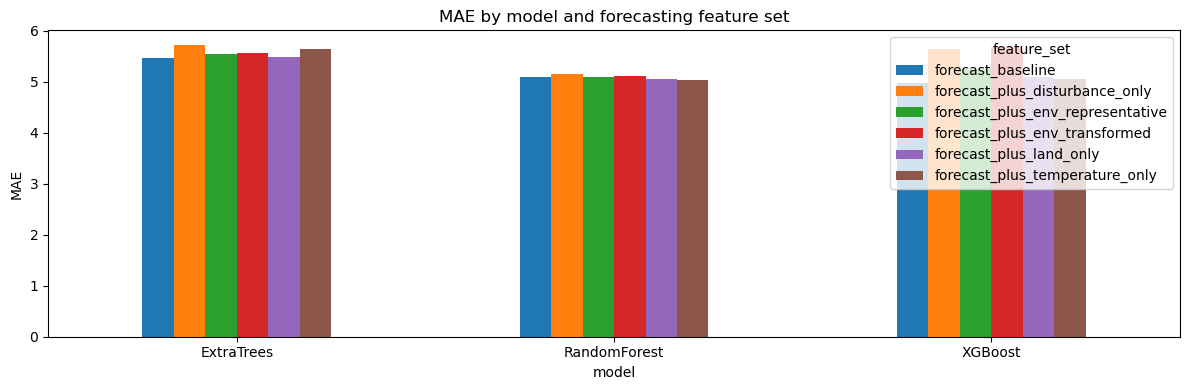

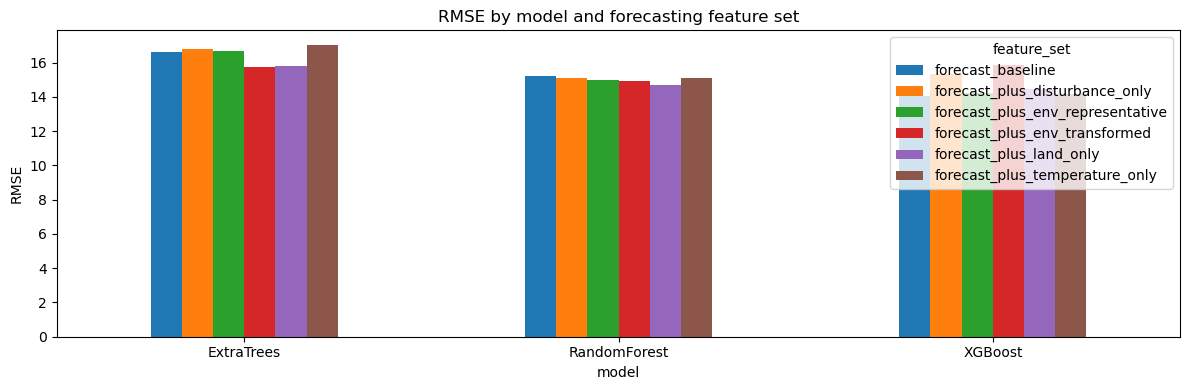

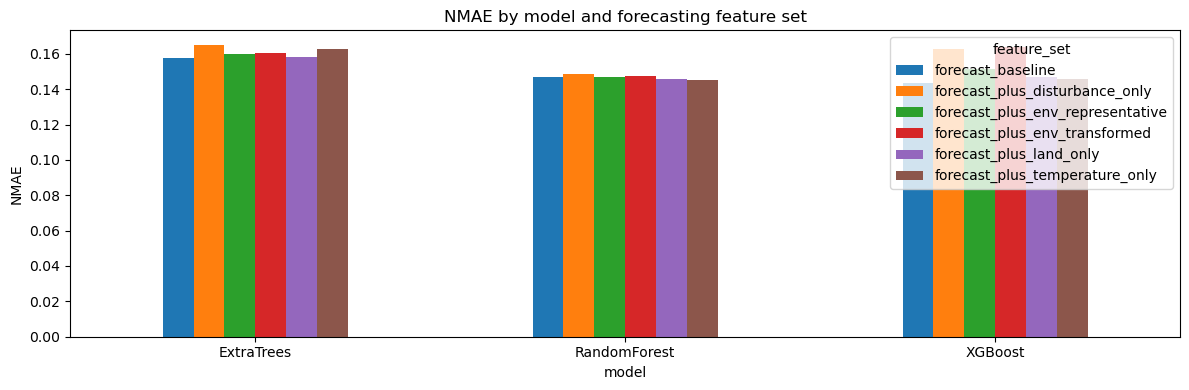

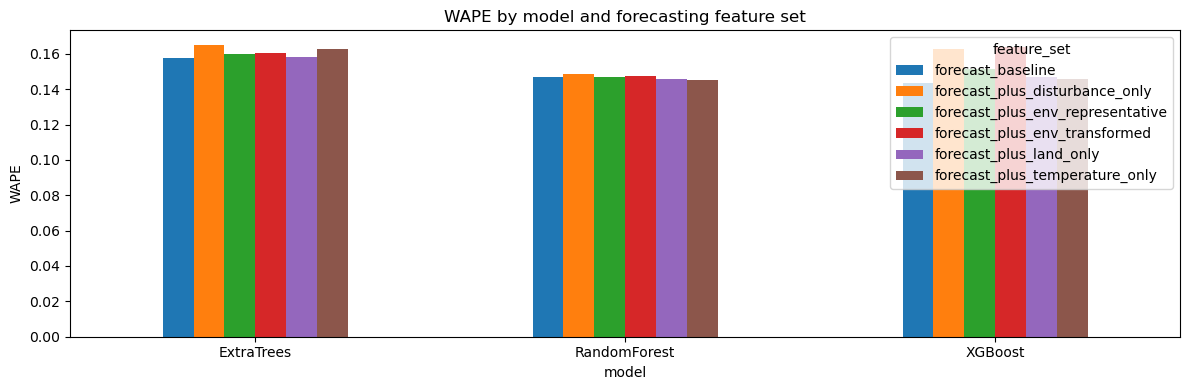

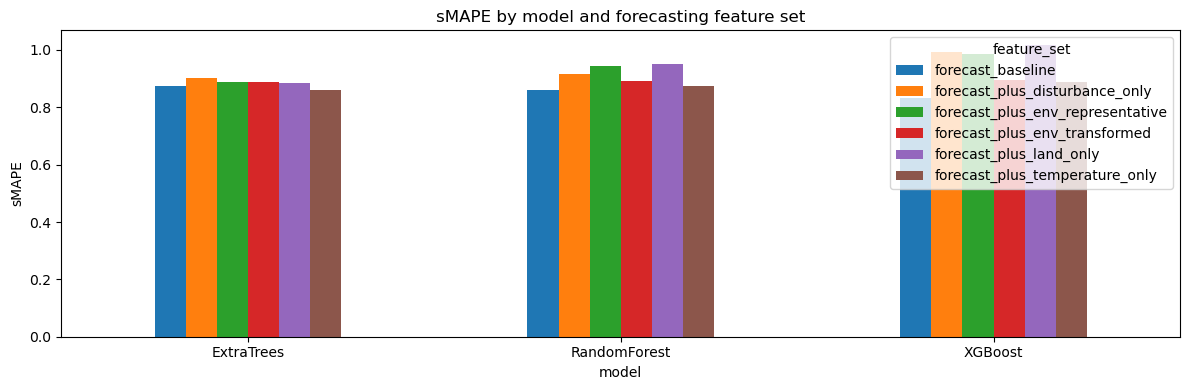

In [18]:
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    pivot = forecast_results_df.pivot(index="model", columns="feature_set", values=metric)
    ax = pivot.plot(kind="bar", figsize=(12, 4), rot=0, title=f"{metric} by model and forecasting feature set")
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

### TRACK B - GLOBAL ENVIRONMENTAL DRIVER EXPERIMENTS

This track removes biodiversity lags and uses environmental predictors to explain annual population change rather than raw population level.

The target is `pop_change_log`, defined as the year-to-year change in log population.  
This makes the driver analysis more aligned with trend dynamics.

In [ ]:
driver_long = merged_long.dropna(subset=["pop_change_log"]).copy()

DRIVER_EXPERIMENTS = {
    "driver_representative": {
        "numeric": ENV_REPRESENTATIVE_FEATURES,
        "categorical": [],
    },
    "driver_transformed": {
        "numeric": ENV_ONLY_DRIVER_FEATURES,
        "categorical": [],
    },
}

driver_train, driver_test, driver_test_years = temporal_split(driver_long, test_years=min(3, GLOBAL_TEST_YEARS))

driver_results_all = []
driver_fitted_models = {}

for label, cfg in DRIVER_EXPERIMENTS.items():
    res, fitted = fit_evaluate_models(
        train_df=driver_train,
        test_df=driver_test,
        target_col="pop_change_log",
        numeric_features=cfg["numeric"],
        categorical_features=cfg["categorical"],
        label=label,
        predict_on_original_scale=False,
    )
    driver_results_all.append(res)
    driver_fitted_models[label] = fitted

driver_results_df = pd.concat(driver_results_all, ignore_index=True)
display(driver_results_df.sort_values(["model", "feature_set"]))

,feature_set,model,n_train,n_test,target,train_MAE,train_RMSE,train_NMAE,MAE,RMSE,NMAE,WAPE,sMAPE
1,driver_representative,ExtraTrees,1153,147,pop_change_log,0.349149,0.507888,0.991452,0.538495,0.748803,1.287881,1.287881,1.663101
4,driver_transformed,ExtraTrees,1153,147,pop_change_log,0.347802,0.507499,0.987627,0.491125,0.709146,1.174591,1.174591,1.677130
0,driver_representative,RandomForest,1153,147,pop_change_log,0.349370,0.508028,0.992079,0.546383,0.779891,1.306747,1.306747,1.683742
3,driver_transformed,RandomForest,1153,147,pop_change_log,0.349122,0.507868,0.991375,0.494889,0.701750,1.183591,1.183591,1.628217
2,driver_representative,XGBoost,1153,147,pop_change_log,0.346113,0.507319,0.982831,0.517400,0.746388,1.237430,1.237430,1.689151
5,driver_transformed,XGBoost,1153,147,pop_change_log,0.346011,0.507314,0.982542,0.521327,0.718618,1.246823,1.246823,1.604042


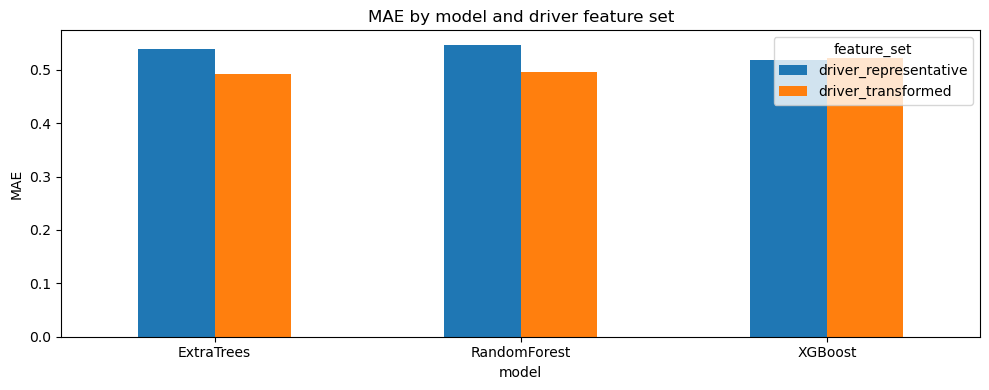

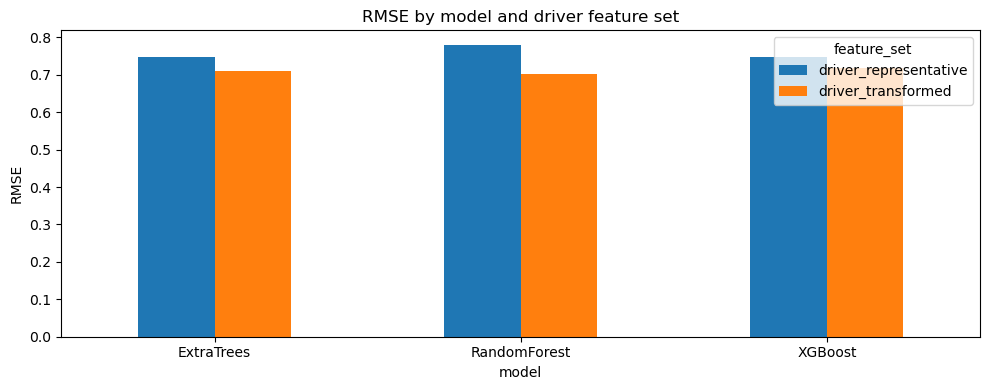

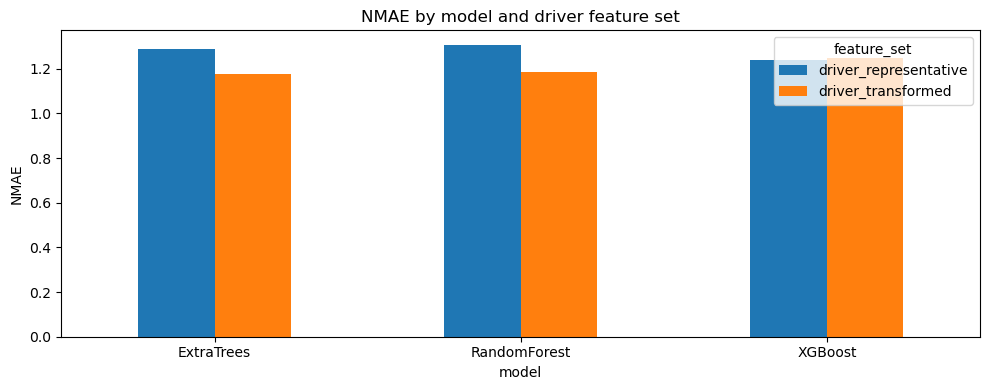

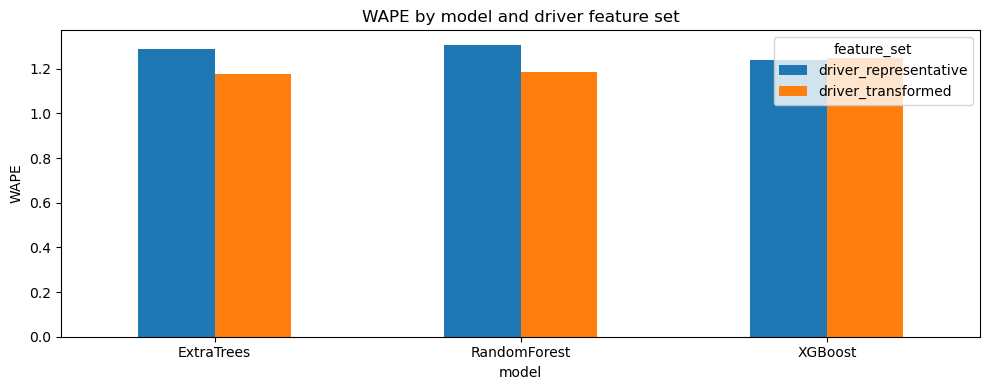

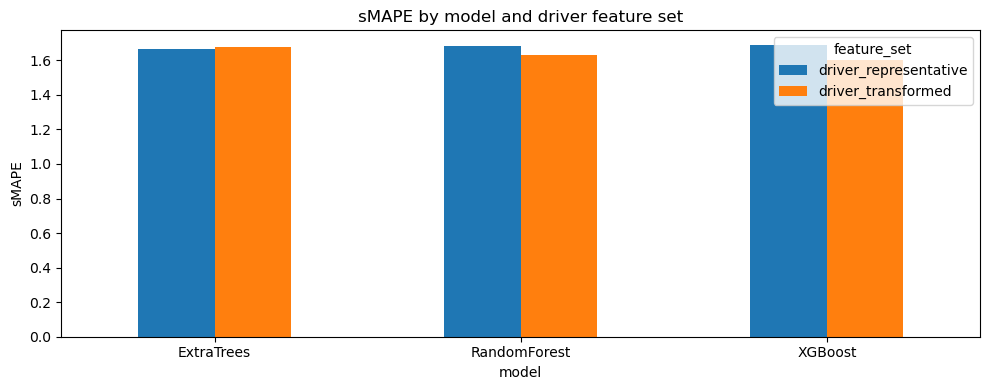

In [ ]:
for metric in ["MAE", "RMSE", "NMAE", "WAPE", "sMAPE"]:
    pivot = driver_results_df.pivot(index="model", columns="feature_set", values=metric)
    ax = pivot.plot(kind="bar", figsize=(10, 4), rot=0, title=f"{metric} by model and driver feature set")
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

### PERMUTATION IMPORTANCE

For forecasting, importance is computed on the enriched forecasting model to see which variables matter after biodiversity lags are already present.  
For driver analysis, importance is computed on the environmental-only model to identify the relative contribution of climate and anthropogenic predictors to annual change.

In [ ]:
def compute_model_permutation_importance(
    pipeline,
    X,
    y,
    numeric_features,
    categorical_features,
    n_repeats=10,
    random_state=42,
):
    result = permutation_importance(
        pipeline,
        X,
        y,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
        scoring="neg_mean_absolute_error",
    )
    feature_names = numeric_features + categorical_features
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean[:len(feature_names)],
        "importance_std": result.importances_std[:len(feature_names)],
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    return imp_df

forecast_enriched_label = "forecast_plus_env_transformed"
forecast_best_model_name = (
    forecast_results_df[forecast_results_df["feature_set"] == forecast_enriched_label]
    .sort_values("NMAE")
    .iloc[0]["model"]
)
forecast_best_pipeline = forecast_fitted_models[forecast_enriched_label][forecast_best_model_name]
forecast_best_cfg = FORECAST_EXPERIMENTS[forecast_enriched_label]

X_forecast_test = forecast_test[forecast_best_cfg["numeric"] + forecast_best_cfg["categorical"]].copy()
y_forecast_test = forecast_test["log_population"].copy()

forecast_importance_df = compute_model_permutation_importance(
    forecast_best_pipeline,
    X_forecast_test,
    y_forecast_test,
    forecast_best_cfg["numeric"],
    forecast_best_cfg["categorical"],
)
display(forecast_importance_df.head(20))

,feature,importance_mean,importance_std
0,lag_1,0.705730,0.037241
1,rolling_mean_3,0.292538,0.026395
2,lag_4,0.034929,0.003506
3,lag_2,0.031024,0.002930
4,lag_3,0.011712,0.002050
5,rolling_std_3,0.009897,0.002553
6,agricultural_land_change_1y,0.002910,0.001706
7,longitude,0.002684,0.000814
8,population_difference,0.001872,0.000461
9,latitude,0.001605,0.001979


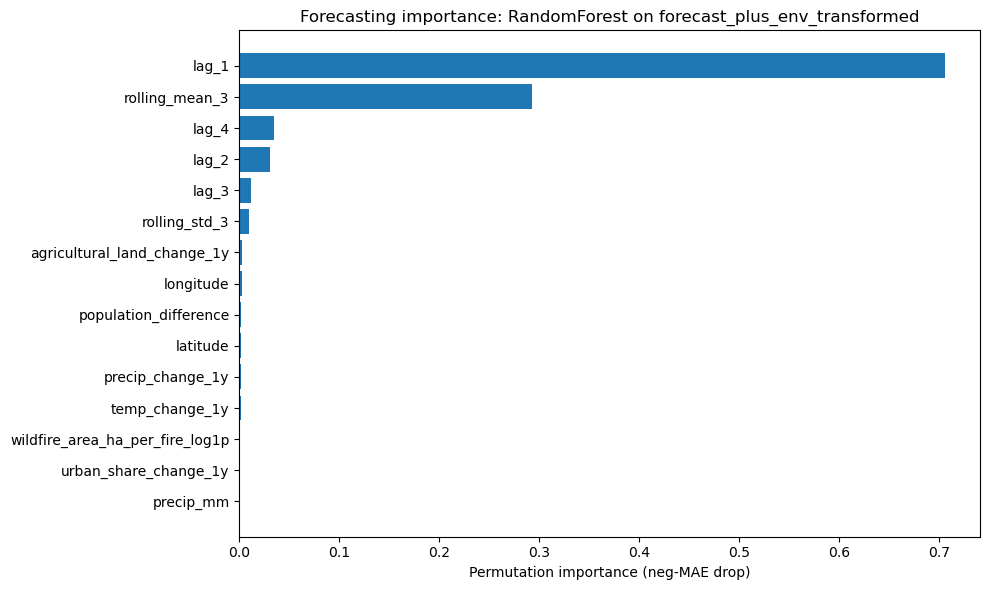

In [22]:
plt.figure(figsize=(10, 6))
plot_imp = forecast_importance_df.head(15).sort_values("importance_mean")
plt.barh(plot_imp["feature"], plot_imp["importance_mean"])
plt.xlabel("Permutation importance (neg-MAE drop)")
plt.title(f"Forecasting importance: {forecast_best_model_name} on {forecast_enriched_label}")
plt.tight_layout()
plt.show()


In [23]:
driver_enriched_label = "driver_transformed"
driver_best_model_name = (
    driver_results_df[driver_results_df["feature_set"] == driver_enriched_label]
    .sort_values("NMAE")
    .iloc[0]["model"]
)
driver_best_pipeline = driver_fitted_models[driver_enriched_label][driver_best_model_name]
driver_best_cfg = DRIVER_EXPERIMENTS[driver_enriched_label]

X_driver_test = driver_test[driver_best_cfg["numeric"] + driver_best_cfg["categorical"]].copy()
y_driver_test = driver_test["pop_change_log"].copy()

driver_importance_df = compute_model_permutation_importance(
    driver_best_pipeline,
    X_driver_test,
    y_driver_test,
    driver_best_cfg["numeric"],
    driver_best_cfg["categorical"],
)
display(driver_importance_df.head(20))


,feature,importance_mean,importance_std
0,wildfire_change_1y,0.005211,0.002764
1,wildfire_area_ha_per_fire_log1p,0.002197,0.000562
2,temp_roll3,0.001282,0.000217
3,agricultural_land_log1p,0.000645,0.000085
4,wildfire_roll3,0.000559,0.000273
5,temp_avg_c,0.000403,0.000371
6,urban_share_change_1y,0.000158,0.000181
7,forest_share_change_1y,0.000081,0.000059
8,wildfire_occurrence,0.000000,0.000000
9,forest_share_pct,-0.000015,0.000047


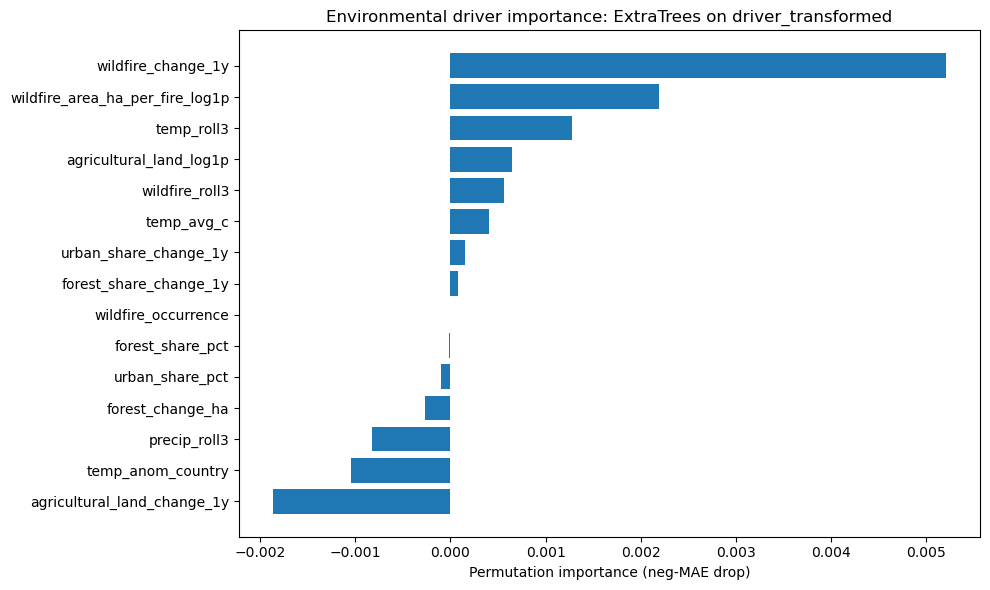

In [24]:
plt.figure(figsize=(10, 6))
plot_imp = driver_importance_df.head(15).sort_values("importance_mean")
plt.barh(plot_imp["feature"], plot_imp["importance_mean"])
plt.xlabel("Permutation importance (neg-MAE drop)")
plt.title(f"Environmental driver importance: {driver_best_model_name} on {driver_enriched_label}")
plt.tight_layout()
plt.show()


### POPULATION LEVEL UTILITIES

The final analysis function uses two separate models internally:

1. Forecast model  
A global lag-based forecasting model fit on the full forecasting panel.

2. Local driver model  
A population-specific environmental model fit on annual population change, without biodiversity lags.

This design keeps prediction and interpretation conceptually separate.

In [25]:
def fit_full_forecast_model(
    model_long,
    experiment_label="forecast_plus_env_transformed",
    model_name=None,
):
    cfg = FORECAST_EXPERIMENTS[experiment_label]
    train_df, test_df, test_years = temporal_split(model_long, test_years=GLOBAL_TEST_YEARS)
    result_df, fitted_models = fit_evaluate_models(
        train_df=train_df,
        test_df=test_df,
        target_col="log_population",
        numeric_features=cfg["numeric"],
        categorical_features=cfg["categorical"],
        label=experiment_label,
        predict_on_original_scale=True,
    )

    if model_name is None:
        model_name = result_df.sort_values("NMAE").iloc[0]["model"]

    chosen_pipeline = fitted_models[model_name]

    full_pipe = Pipeline([
        ("preprocessor", make_preprocessor(cfg["numeric"], cfg["categorical"])),
        ("model", clone(chosen_pipeline.named_steps["model"])),
    ])
    full_pipe.fit(model_long[cfg["numeric"] + cfg["categorical"]], model_long["log_population"])

    pred_backtest = chosen_pipeline.predict(test_df[cfg["numeric"] + cfg["categorical"]])
    residual_std_log = float(np.std(test_df["log_population"] - pred_backtest))

    return {
        "pipeline": full_pipe,
        "experiment_label": experiment_label,
        "model_name": model_name,
        "numeric_features": cfg["numeric"],
        "categorical_features": cfg["categorical"],
        "backtest_results": result_df,
        "residual_std_log": residual_std_log,
    }

FULL_FORECAST_MODEL = fit_full_forecast_model(
    forecast_long,
    experiment_label=forecast_enriched_label,
    model_name=forecast_best_model_name,
)

display(FULL_FORECAST_MODEL["backtest_results"].sort_values("NMAE"))
print("Selected full forecast model:", FULL_FORECAST_MODEL["model_name"])
print("Residual std on log scale:", round(FULL_FORECAST_MODEL["residual_std_log"], 4))


,feature_set,model,n_train,n_test,target,train_MAE,train_RMSE,train_NMAE,MAE,RMSE,NMAE,WAPE,sMAPE
0,forecast_plus_env_transformed,RandomForest,909,244,log_population,1.795367,5.205606,0.073657,5.119539,14.925675,0.147620,0.147620,0.892016
1,forecast_plus_env_transformed,ExtraTrees,909,244,log_population,1.087505,3.162907,0.044616,5.572739,15.712923,0.160688,0.160688,0.888887
2,forecast_plus_env_transformed,XGBoost,909,244,log_population,0.623888,2.035592,0.025596,5.689338,15.860461,0.164050,0.164050,0.896457


Selected full forecast model: RandomForest
Residual std on log scale: 0.4635


In [ ]:
def fit_local_driver_model(
    population_df,
    feature_cols,
    min_train_rows=8,
    random_state=42,
):
    population_df = population_df.dropna(subset=["pop_change_log"]).sort_values("Year").copy()
    if len(population_df) < max(6, min_train_rows):
        return {
            "status": "insufficient_data",
            "message": "Not enough observations to fit a stable local driver model.",
            "top_drivers": [],
            "importance_df": pd.DataFrame(columns=["feature", "importance_mean", "importance_std", "contribution_pct"]),
        }

    split_n = max(2, min(4, len(population_df) // 4))
    train_df = population_df.iloc[:-split_n].copy()
    test_df = population_df.iloc[-split_n:].copy()

    if len(train_df) < min_train_rows:
        train_df = population_df.copy()
        test_df = population_df.copy()
        note = "Permutation importance computed on the full series because the population is too short for a reliable holdout split."
    else:
        note = "Permutation importance computed on the last observed years of the population."

    numeric_features = [c for c in feature_cols if c in population_df.columns]
    pipe = Pipeline([
        ("preprocessor", make_preprocessor(numeric_features, [])),
        ("model", RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=1,
            n_jobs=-1,
            random_state=random_state,
        )),
    ])
    pipe.fit(train_df[numeric_features], train_df["pop_change_log"])

    imp_df = compute_model_permutation_importance(
        pipe,
        test_df[numeric_features],
        test_df["pop_change_log"],
        numeric_features,
        [],
        n_repeats=20,
        random_state=random_state,
    )

    imp_positive = imp_df.copy()
    imp_positive["importance_pos"] = imp_positive["importance_mean"].clip(lower=0)

    if imp_positive["importance_pos"].sum() > 0:
        imp_positive["contribution_pct"] = 100 * imp_positive["importance_pos"] / imp_positive["importance_pos"].sum()
        top_drivers = (
            imp_positive.sort_values("contribution_pct", ascending=False)
            .loc[lambda d: d["contribution_pct"] > 0, ["feature", "contribution_pct", "importance_mean"]]
            .head(3)
            .to_dict(orient="records")
        )
        message = note
    else:
        imp_positive["contribution_pct"] = 0.0
        top_drivers = []
        message = note + " No positive environmental contribution was found under this setup."

    return {
        "status": "ok",
        "message": message,
        "top_drivers": top_drivers,
        "importance_df": imp_positive.sort_values("importance_mean", ascending=False).reset_index(drop=True),
        "pipeline": pipe,
    }

In [ ]:
RAW_ENV_COLS = [c for c in [
    "temp_avg_c", "precip_mm", "forest_share_pct", "forest_change_ha",
    "agricultural_land_log1p", "wildfire_area_ha_per_fire_log1p", "urban_share_pct"
] if c in env_panel.columns]

def project_country_environment(
    env_country_df,
    future_years,
    strategy="last_value",
    trend_window=10,
):
    hist = env_country_df.sort_values("Year").copy()
    if hist.empty:
        raise ValueError("No environmental history available for the selected country.")

    all_years = set(hist["Year"].tolist())
    future_rows = []

    for year in future_years:
        if year in all_years:
            continue

        row = {"country_norm": hist["country_norm"].iloc[0], "Year": year}

        for col in RAW_ENV_COLS:
            series = hist[["Year", col]].dropna().copy()

            if year in hist["Year"].values:
                row[col] = hist.loc[hist["Year"] == year, col].iloc[0]
                continue

            if len(series) == 0:
                row[col] = np.nan
            elif strategy == "linear_trend" and len(series) >= 3:
                recent = series.tail(min(trend_window, len(series)))
                x = recent["Year"].values
                y = recent[col].values
                slope, intercept = np.polyfit(x, y, 1)
                row[col] = float(intercept + slope * year)
            else:
                row[col] = float(series.iloc[-1][col])

        future_rows.append(row)
        hist = pd.concat([hist, pd.DataFrame([row])], ignore_index=True)
        hist = hist.sort_values(["country_norm", "Year"]).reset_index(drop=True)

    hist = add_environmental_features(hist)
    return hist

def z_value_for_ci(level=0.90):
    mapping = {0.80: 1.282, 0.90: 1.645, 0.95: 1.960, 0.99: 2.576}
    return mapping.get(level, 1.645)

In [ ]:
def get_population_metadata(df, population_id):
    cols = [c for c in [
        "population_id", "binomial", "common_name", "class", "family", "country",
        "location", "units", "t_realm", "t_biome", "ipbes_subregion", "latitude", "longitude"
    ] if c in df.columns]
    meta = df[df["population_id"].astype(str) == str(population_id)][cols].drop_duplicates()
    if meta.empty:
        raise ValueError(f"Population ID {population_id} not found.")
    return meta.iloc[0].to_dict()

def recursive_forecast_population(
    population_id,
    horizon_years,
    full_forecast_model,
    merged_long_df,
    forecast_long_df,
    env_panel_df,
    future_env_strategy="last_value",
    ci_level=0.90,
):
    if horizon_years < 1 or horizon_years > MAX_FORECAST_HORIZON:
        raise ValueError(f"horizon_years must be between 1 and {MAX_FORECAST_HORIZON}")

    pop_id = str(population_id)
    hist_rows = merged_long_df[merged_long_df["population_id"].astype(str) == pop_id].sort_values("Year").copy()
    if hist_rows.empty:
        raise ValueError(f"Population ID {population_id} not found in merged panel.")

    metadata = get_population_metadata(merged_long_df, pop_id)
    country_norm = hist_rows["country_norm"].dropna().iloc[0]
    last_year = int(hist_rows["Year"].max())
    future_years = list(range(last_year + 1, last_year + 1 + horizon_years))

    country_env_hist = env_panel_df[env_panel_df["country_norm"] == country_norm].copy()
    if country_env_hist.empty:
        raise ValueError(f"No environmental history found for country '{country_norm}'.")

    env_extended = project_country_environment(
        country_env_hist,
        future_years=future_years,
        strategy=future_env_strategy,
    )

    pipeline = full_forecast_model["pipeline"]
    numeric_features = full_forecast_model["numeric_features"]
    categorical_features = full_forecast_model["categorical_features"]
    residual_std_log = full_forecast_model["residual_std_log"]

    history = hist_rows[["population_id", "Year", "Population"]].copy().sort_values("Year").reset_index(drop=True)
    records_for_config = []

    for _, row in history.iterrows():
        records_for_config.append({
            "year": int(row["Year"]),
            "observed_population": float(row["Population"]),
            "forecast_population": None,
            "fitted_population": None,
            "lower_ci": None,
            "upper_ci": None,
            "segment": "record",
        })

    pred_rows = []
    current_history = history.copy()

    z = z_value_for_ci(ci_level)

    static_values = {}
    for c in STATIC_NUMERIC_FEATURES + STATIC_CATEGORICAL_FEATURES:
        if c in hist_rows.columns:
            vals = hist_rows[c].dropna()
            static_values[c] = vals.iloc[0] if len(vals) else np.nan

    for step, year in enumerate(future_years, start=1):
        recent = current_history.sort_values("Year").copy()

        feature_row = {
            "Year": year,
        }

        for lag in range(1, N_LAGS + 1):
            feature_row[f"lag_{lag}"] = recent["Population"].iloc[-lag] if len(recent) >= lag else np.nan

        feature_row["year_gap_from_prev"] = year - recent["Year"].iloc[-1] if len(recent) else np.nan
        feature_row["rolling_mean_3"] = recent["Population"].tail(3).mean() if len(recent) >= 1 else np.nan
        feature_row["rolling_std_3"] = recent["Population"].tail(3).std(ddof=1) if len(recent) >= 2 else np.nan
        feature_row["population_difference"] = (
            feature_row.get("lag_1", np.nan) - feature_row.get("lag_2", np.nan)
            if not pd.isna(feature_row.get("lag_1", np.nan)) and not pd.isna(feature_row.get("lag_2", np.nan))
            else np.nan
        )
        lag1 = feature_row.get("lag_1", np.nan)
        lag2 = feature_row.get("lag_2", np.nan)
        feature_row["population_growth_rate"] = (
            (lag1 - lag2) / lag2 if pd.notna(lag1) and pd.notna(lag2) and lag2 != 0 else np.nan
        )

        env_year_row = env_extended[env_extended["Year"] == year]
        if env_year_row.empty:
            raise ValueError(f"Missing future environmental row for year {year}")
        env_year_row = env_year_row.iloc[0].to_dict()

        for c in ENV_TRANSFORMED_FEATURES + ENV_REPRESENTATIVE_FEATURES + RAW_ENV_COLS:
            if c in env_extended.columns:
                feature_row[c] = env_year_row.get(c, np.nan)

        for c, v in static_values.items():
            feature_row[c] = v

        X_future = pd.DataFrame([feature_row])[numeric_features + categorical_features]
        pred_log = float(pipeline.predict(X_future)[0])
        pred_pop = float(np.clip(np.expm1(pred_log), a_min=0, a_max=None))

        lower_log = pred_log - z * residual_std_log * math.sqrt(step)
        upper_log = pred_log + z * residual_std_log * math.sqrt(step)
        lower_pop = float(np.clip(np.expm1(lower_log), a_min=0, a_max=None))
        upper_pop = float(np.clip(np.expm1(upper_log), a_min=0, a_max=None))

        pred_rows.append({
            "year": year,
            "forecast_population": pred_pop,
            "lower_ci": lower_pop,
            "upper_ci": upper_pop,
            "feature_row": feature_row,
        })

        current_history = pd.concat([
            current_history,
            pd.DataFrame([{
                "population_id": pop_id,
                "Year": year,
                "Population": pred_pop,
            }])
        ], ignore_index=True)

    forecast_df = pd.DataFrame(pred_rows)
    return {
        "metadata": metadata,
        "history_df": hist_rows.sort_values("Year").copy(),
        "forecast_df": forecast_df,
        "env_extended": env_extended,
        "ci_level": ci_level,
        "future_env_strategy": future_env_strategy,
    }

In [ ]:
def lookup_iucn(binomial, current_lookup_path=None, future_lookup_path=None, target_year=None):
    out = {
        "current_iucn": None,
        "current_assessment_year": None,
        "future_iucn": None,
        "future_scenario_name": None,
    }

    if binomial is None or pd.isna(binomial):
        return out

    binomial = str(binomial)

    if current_lookup_path is not None and Path(current_lookup_path).exists():
        cur = pd.read_csv(current_lookup_path)
        cur_match = cur[cur["binomial"].astype(str) == binomial]
        if not cur_match.empty:
            row = cur_match.iloc[0]
            out["current_iucn"] = row.get("iucn_category")
            out["current_assessment_year"] = row.get("assessment_year")

    if future_lookup_path is not None and Path(future_lookup_path).exists() and target_year is not None:
        fut = pd.read_csv(future_lookup_path)
        fut_match = fut[(fut["binomial"].astype(str) == binomial) & (pd.to_numeric(fut["target_year"], errors="coerce") == int(target_year))]
        if not fut_match.empty:
            row = fut_match.iloc[0]
            out["future_iucn"] = row.get("projected_iucn_category")
            out["future_scenario_name"] = row.get("scenario_name")

    return out

def make_driver_percentages(top_drivers):
    if not top_drivers:
        return []
    total = sum(max(0, d.get("contribution_pct", 0)) for d in top_drivers)
    if total <= 0:
        return []
    clean = []
    for d in top_drivers:
        pct = 100 * max(0, d.get("contribution_pct", 0)) / total
        clean.append({
            "feature": d["feature"],
            "contribution_pct": float(pct),
            "importance_mean": float(d.get("importance_mean", np.nan)),
        })
    return clean

In [ ]:
def plot_population_forecast(result):
    meta = result["metadata"]
    hist = result["history_df"].sort_values("Year")
    fc = result["forecast_df"].sort_values("year")

    plt.figure(figsize=(12, 5))
    plt.plot(hist["Year"], hist["Population"], label="Observed records", linewidth=2)
    plt.plot(fc["year"], fc["forecast_population"], label="Forecast", linewidth=2)
    plt.fill_between(fc["year"], fc["lower_ci"], fc["upper_ci"], alpha=0.2, label=f"{int(result['ci_level']*100)}% CI")
    plt.title(f"Population forecast | {meta.get('common_name', meta.get('binomial', meta.get('population_id')))}")
    plt.xlabel("Year")
    plt.ylabel("Population")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_top_drivers(driver_result):
    imp = driver_result["importance_df"].copy()
    imp = imp[imp["contribution_pct"] > 0].head(10).sort_values("contribution_pct")
    if imp.empty:
        print(driver_result["message"])
        return

    plt.figure(figsize=(8, 4))
    plt.barh(imp["feature"], imp["contribution_pct"])
    plt.xlabel("Contribution (%)")
    plt.title("Top environmental drivers")
    plt.tight_layout()
    plt.show()

In [31]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

def export_population_config(config_dict, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(config_dict, f, ensure_ascii=False, indent=2)

    return output_path


def analyze_population(
    population_id,
    horizon_years=5,
    future_env_strategy="last_value",
    current_iucn_lookup_path=IUCN_CURRENT_PATH,
    future_iucn_lookup_path=IUCN_FUTURE_PATH,
    export_json=True,
    export_dir=REPORT_DIR,
    ci_level=0.90,
):
    """
    Analyze one population with two separate tracks:
    1. Forecasting model with biodiversity lags
    2. Local environmental driver model without biodiversity lags

    Parameters
    ----------
    population_id : str or int
        Population identifier.
    horizon_years : int, default=5
        Forecast horizon in years. Cannot exceed MAX_FORECAST_HORIZON.
    future_env_strategy : str, default="last_value"
        Strategy used to fill future environmental values.
    current_iucn_lookup_path : Path or None
        Path to current IUCN lookup file.
    future_iucn_lookup_path : Path or None
        Path to future IUCN scenario lookup file.
    export_json : bool, default=True
        Whether to export the config JSON.
    export_dir : Path-like, default=REPORT_DIR
        Directory where the JSON report will be saved.
    ci_level : float, default=0.90
        Confidence interval level for the forecast.

    Returns
    -------
    dict
        Dictionary with forecast result, driver result, exported config, and JSON path.
    """

    if horizon_years > MAX_FORECAST_HORIZON:
        raise ValueError(f"Horizon cannot exceed {MAX_FORECAST_HORIZON} years.")

    population_id = str(population_id)
    export_dir = Path(export_dir)

    # -----------------------------
    # 1. Historical population slice
    # -----------------------------
    pop_hist = (
        merged_long[merged_long["population_id"].astype(str) == population_id]
        .sort_values("Year")
        .copy()
    )

    if pop_hist.empty:
        raise ValueError(f"No records found for population_id={population_id}")

    # -----------------------------
    # 2. Forecasting track
    # -----------------------------
    forecast_result = recursive_forecast_population(
        population_id=population_id,
        horizon_years=horizon_years,
        full_forecast_model=FULL_FORECAST_MODEL,
        merged_long_df=merged_long,
        forecast_long_df=forecast_long,
        env_panel_df=env_panel,
        future_env_strategy=future_env_strategy,
        ci_level=ci_level,
    )

    # -----------------------------
    # 3. Local driver track
    # -----------------------------
    local_driver = fit_local_driver_model(
        population_df=pop_hist,
        feature_cols=ENV_ONLY_DRIVER_FEATURES,
        min_train_rows=8,
        random_state=RANDOM_STATE,
    )

    # -----------------------------
    # 4. Metadata
    # -----------------------------
    metadata = forecast_result.get("metadata", {})
    binomial = metadata.get("binomial")

    forecast_df = forecast_result.get("forecast_df", pd.DataFrame()).copy()
    if not forecast_df.empty:
        target_year = int(forecast_df["year"].max())
    else:
        target_year = None

    # -----------------------------
    # 5. IUCN lookup (safe fallback)
    # -----------------------------
    if binomial is not None and current_iucn_lookup_path is not None:
        try:
            iucn_info = lookup_iucn(
                binomial=binomial,
                current_lookup_path=current_iucn_lookup_path,
                future_lookup_path=future_iucn_lookup_path,
                target_year=target_year,
            )
        except Exception as e:
            iucn_info = {
                "binomial": binomial,
                "current_iucn": None,
                "future_iucn": None,
                "target_year": target_year,
                "note": f"IUCN lookup failed: {e}",
            }
    else:
        iucn_info = {
            "binomial": binomial,
            "current_iucn": None,
            "future_iucn": None,
            "target_year": target_year,
            "note": "IUCN lookup not available",
        }

    # -----------------------------
    # 6. Driver percentages
    # -----------------------------
    # Expected behavior:
    # - normalize only positive importances
    # - if no positive contributions exist, return an empty list or a note
    try:
        top_drivers = make_driver_percentages(local_driver.get("top_drivers", []))
    except Exception:
        top_drivers = []

    # -----------------------------
    # 7. Config dictionary for export / UI
    # -----------------------------
    config_dict = {
        "population_id": population_id,
        "species_binomial": binomial,
        "common_name": metadata.get("common_name"),
        "country": metadata.get("country"),
        "location": metadata.get("location"),
        "last_observed_year": int(pop_hist["Year"].max()),
        "prediction_horizon_years": int(horizon_years),
        "future_environment_strategy": future_env_strategy,
        "forecast_model": {
            "feature_set": FULL_FORECAST_MODEL.get("experiment_label"),
            "model_name": FULL_FORECAST_MODEL.get("model_name"),
            "ci_level": float(ci_level),
            "residual_std_log": float(FULL_FORECAST_MODEL.get("residual_std_log", np.nan)),
        },
        "historical_records": [
            {
                "year": int(r["Year"]),
                "population": float(r["Population"]),
            }
            for _, r in (
                pop_hist[["Year", "Population"]]
                .sort_values("Year")
                .iterrows()
            )
        ],
        "forecast_records": [
            {
                "year": int(r["year"]),
                "forecast_population": float(r["forecast_population"]),
                "lower_ci": float(r["lower_ci"]),
                "upper_ci": float(r["upper_ci"]),
            }
            for _, r in forecast_df.sort_values("year").iterrows()
        ] if not forecast_df.empty else [],
        "top_environmental_drivers": top_drivers,
        "driver_note": local_driver.get("message"),
        "iucn": iucn_info,
        "plot_config": {
            "record_color": "#1f77b4",
            "forecast_color": "#ff7f0e",
            "ci_alpha": 0.2,
        },
    }

    # -----------------------------
    # 8. Export JSON
    # -----------------------------
    export_path = None
    if export_json:
        export_path = export_population_config(
            config_dict=config_dict,
            output_path=export_dir / f"population_{population_id}_h{horizon_years}.json",
        )

    # -----------------------------
    # 9. Plots in notebook
    # -----------------------------
    plot_population_forecast(forecast_result)
    plot_top_drivers(local_driver)

    if local_driver.get("status") == "ok" and "importance_df" in local_driver:
        display(local_driver["importance_df"].head(10))

    # -----------------------------
    # 10. Summary table
    # -----------------------------
    summary_df = pd.DataFrame([{
        "population_id": config_dict["population_id"],
        "binomial": config_dict["species_binomial"],
        "country": config_dict["country"],
        "last_observed_year": config_dict["last_observed_year"],
        "forecast_until": (
            config_dict["forecast_records"][-1]["year"]
            if len(config_dict["forecast_records"]) > 0 else np.nan
        ),
        "n_top_drivers": len(config_dict["top_environmental_drivers"]),
        "current_iucn": config_dict["iucn"].get("current_iucn"),
        "future_iucn": config_dict["iucn"].get("future_iucn"),
        "json_path": str(export_path) if export_path is not None else None,
    }])

    display(summary_df)

    return {
        "forecast_result": forecast_result,
        "local_driver_result": local_driver,
        "config": config_dict,
        "json_path": str(export_path) if export_path is not None else None,
    }

Quick example

Set a valid `population_id` from the table below, then run the final cell.


In [ ]:
population_lengths = (
    merged_long.groupby("population_id")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="n_rows")
)
display(population_lengths.head(20))

,population_id,n_rows
0,111105,40
1,111106,40
2,110261,39
3,27730,36
4,27563,32
5,27564,32
6,120307,31
7,120306,31
8,120304,31
9,120324,31


In [ ]:
EXAMPLE_POPULATION_ID = DEFAULT_POPULATION_ID or population_lengths.iloc[0]["population_id"]
EXAMPLE_HORIZON_YEARS = 10

print("Example population ID:", EXAMPLE_POPULATION_ID)

Example population ID: 111105


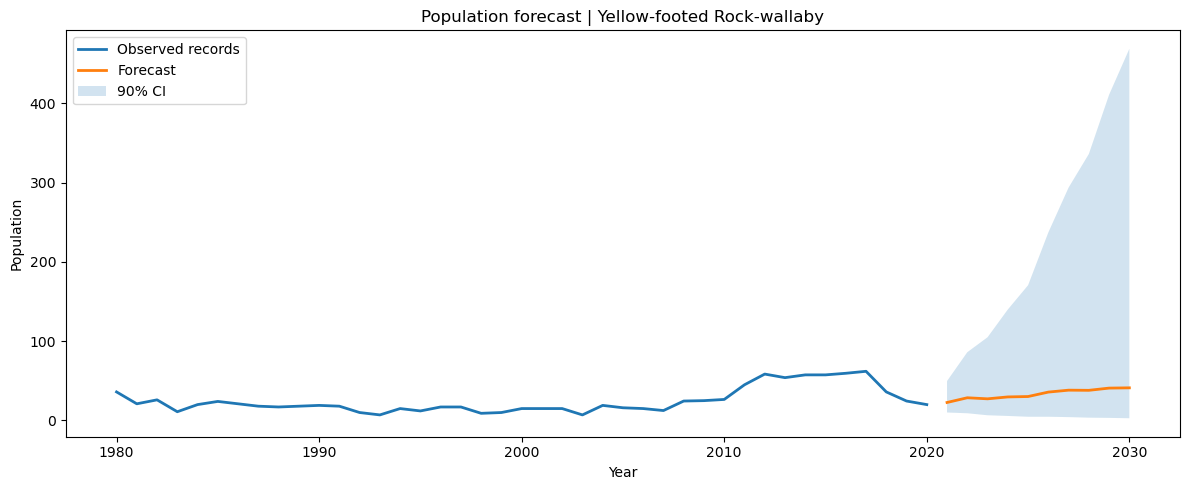

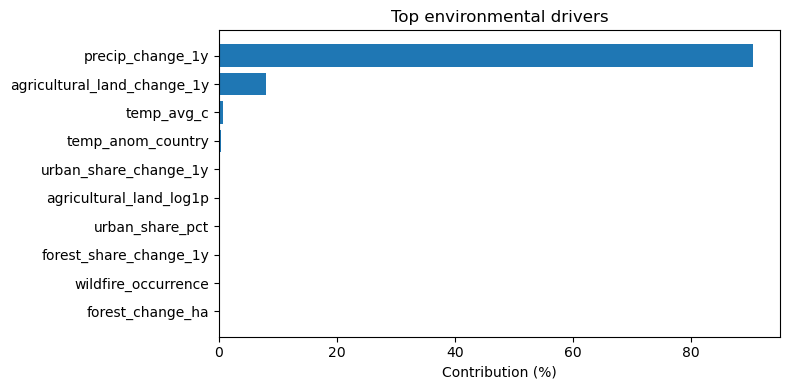

,feature,importance_mean,importance_std,importance_pos,contribution_pct
0,precip_change_1y,2.670228e-02,4.679713e-02,2.670228e-02,9.060397e+01
1,agricultural_land_change_1y,2.363812e-03,1.828902e-03,2.363812e-03,8.020690e+00
2,temp_avg_c,2.123225e-04,3.268370e-04,2.123225e-04,7.204351e-01
3,temp_anom_country,1.215213e-04,3.626017e-04,1.215213e-04,4.123360e-01
4,urban_share_change_1y,6.813101e-05,1.152991e-04,6.813101e-05,2.311765e-01
5,agricultural_land_log1p,3.358245e-06,3.983774e-05,3.358245e-06,1.139492e-02
6,urban_share_pct,5.273559e-17,2.761645e-17,5.273559e-17,1.789380e-13
7,forest_share_change_1y,4.996004e-17,2.419675e-17,4.996004e-17,1.695202e-13
8,wildfire_occurrence,4.718448e-17,2.647713e-17,4.718448e-17,1.601024e-13
9,forest_change_ha,3.885781e-17,2.543841e-17,3.885781e-17,1.318491e-13


,population_id,binomial,country,last_observed_year,forecast_until,n_top_drivers,current_iucn,future_iucn,json_path
0,111105,Petrogale_xanthopus,australia,2020,2030,3,None,None,C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\E...


In [34]:
example_output = analyze_population(
    population_id=EXAMPLE_POPULATION_ID,
    horizon_years=EXAMPLE_HORIZON_YEARS,
    future_env_strategy="last_value",
    export_json=True,
)


What the final JSON export contains

- population metadata
- historical records
- future forecast with lower and upper confidence intervals
- top environmental drivers and contribution percentages when positive signal exists
- optional IUCN current and future scenario values if lookup tables are filled
- a small plot config block for application integration

If the local environmental model finds no positive contribution, the driver list is left empty rather than forcing artificial percentages.


In [35]:
if 'example_output' in globals() and example_output.get("json_path"):
    print("Saved JSON config to:")
    print(example_output["json_path"])

Saved JSON config to:
C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\03_Elevation_Phase\02_Challenge\animal-diversity-prediction\outputs\population_reports\population_111105_h10.json
